# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [3]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below

In [4]:
from  sklearn.model_selection import train_test_split
seed = 31287

In [5]:
data = pd.read_csv('data/banknotes_data.csv')

In [6]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [7]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [9]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [10]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [11]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

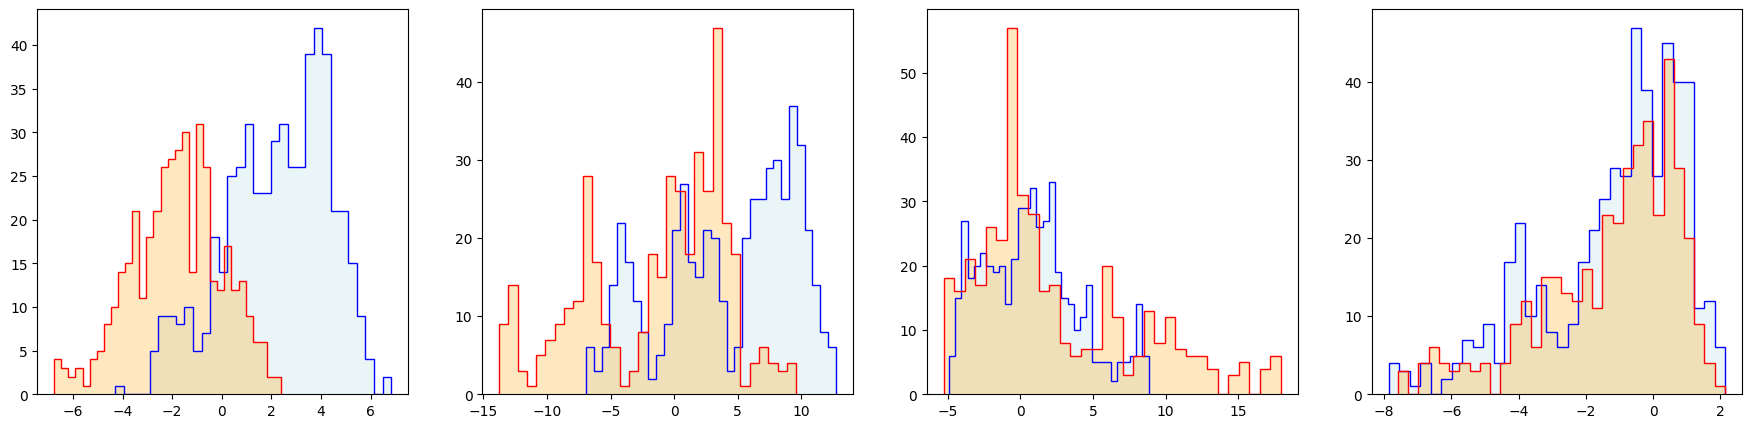

In [12]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

## Problem 2

Using the GaussianNB function construct the Gaussian Bayes classifier using two features. Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot. Additionally, on the test set, compare ROC curve obtained with this 2-features classifier and  1-features classifier (the one from Problem 1, previous classes). What is the improvement of AUC score on the test set when we use 2-features classifier instead of 1-features classifier?

Normalized confusion matrix - Training set (2 features):
 [[0.8957529  0.1042471 ]
 [0.16666667 0.83333333]]

Normalized confusion matrix - Test set (2 features):
 [[0.90769231 0.09230769]
 [0.16346154 0.83653846]]

ROC AUC - Training set (2 features): 0.9500
ROC AUC - Test set (2 features): 0.9638

Improvement of AUC score on test set (2-features vs 1-feature): 0.0195


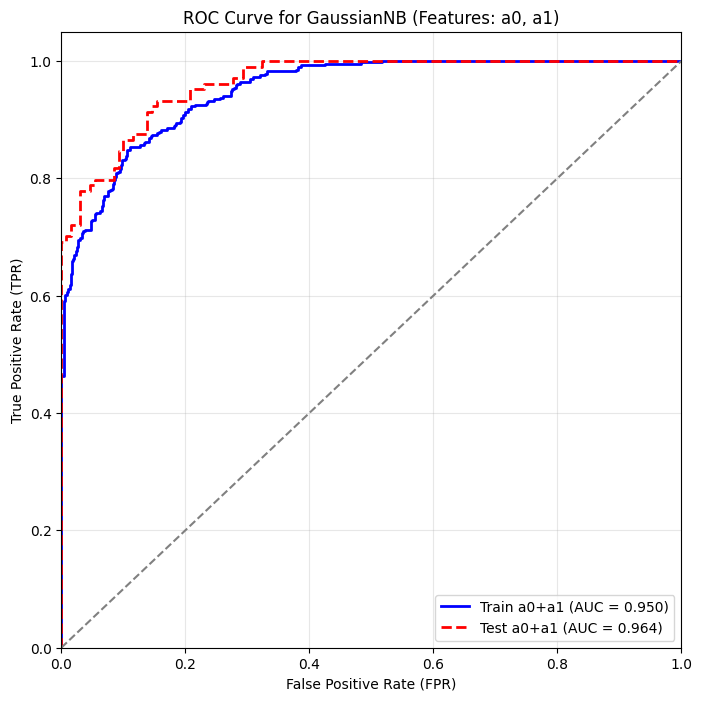

In [13]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

X_train_a0 = data_train[['a0']]
X_test_a0 = data_test[['a0']]
y_train = data_train['counterfeit']
y_test = data_test['counterfeit']

gnb_a0 = GaussianNB().fit(X_train_a0, y_train)
y_test_proba_a0 = gnb_a0.predict_proba(X_test_a0)[:, 1]
auc_test_a0 = roc_auc_score(y_test, y_test_proba_a0)
fprs_test_a0, tprs_test_a0, _ = roc_curve(y_test, y_test_proba_a0)

features_2 = ['a0', 'a1']
X_train_a0a1 = data_train[features_2]
X_test_a0a1 = data_test[features_2]

gnb_a0a1 = GaussianNB()
gnb_a0a1.fit(X_train_a0a1, y_train)

y_train_pred_a0a1 = gnb_a0a1.predict(X_train_a0a1)
y_test_pred_a0a1 = gnb_a0a1.predict(X_test_a0a1)

y_train_proba_a0a1 = gnb_a0a1.predict_proba(X_train_a0a1)[:, 1]
y_test_proba_a0a1 = gnb_a0a1.predict_proba(X_test_a0a1)[:, 1]

cm_train_a0a1 = confusion_matrix(y_train, y_train_pred_a0a1, normalize='true')
cm_test_a0a1 = confusion_matrix(y_test, y_test_pred_a0a1, normalize='true')

print("Normalized confusion matrix - Training set (2 features):\n", cm_train_a0a1)
print("\nNormalized confusion matrix - Test set (2 features):\n", cm_test_a0a1)

auc_train_a0a1 = roc_auc_score(y_train, y_train_proba_a0a1)
auc_test_a0a1 = roc_auc_score(y_test, y_test_proba_a0a1)

print(f"\nROC AUC - Training set (2 features): {auc_train_a0a1:.4f}")
print(f"ROC AUC - Test set (2 features): {auc_test_a0a1:.4f}")

improvement = auc_test_a0a1 - auc_test_a0
print(f"\nImprovement of AUC score on test set (2-features vs 1-feature): {improvement:.4f}")

fprs_train_a0a1, tprs_train_a0a1, _ = roc_curve(y_train, y_train_proba_a0a1)
fprs_test_a0a1, tprs_test_a0a1, _ = roc_curve(y_test, y_test_proba_a0a1)

plt.figure(figsize=(8, 8))
plt.plot(fprs_train_a0a1, tprs_train_a0a1, color='blue', lw=2, 
         label=f'Train a0+a1 (AUC = {auc_train_a0a1:.3f})')
plt.plot(fprs_test_a0a1, tprs_test_a0a1, color='red', lw=2, linestyle='--', 
         label=f'Test a0+a1 (AUC = {auc_test_a0a1:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for GaussianNB (Features: a0, a1)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Problem 3

Same as Problem 2 but now implement Gaussian Naive Bayes using all features. Show confusion matrix only for test set. Compare all three ROC curves on the test set, same with AUC score.

Normalized confusion matrix - Test set (All features):
 [[0.89230769 0.10769231]
 [0.20192308 0.79807692]]

--- Comparison of AUC scores on Test Set ---
1 Feature  (a0):         0.9443
2 Features (a0, a1):     0.9638
All Features (a0 to a3): 0.9521


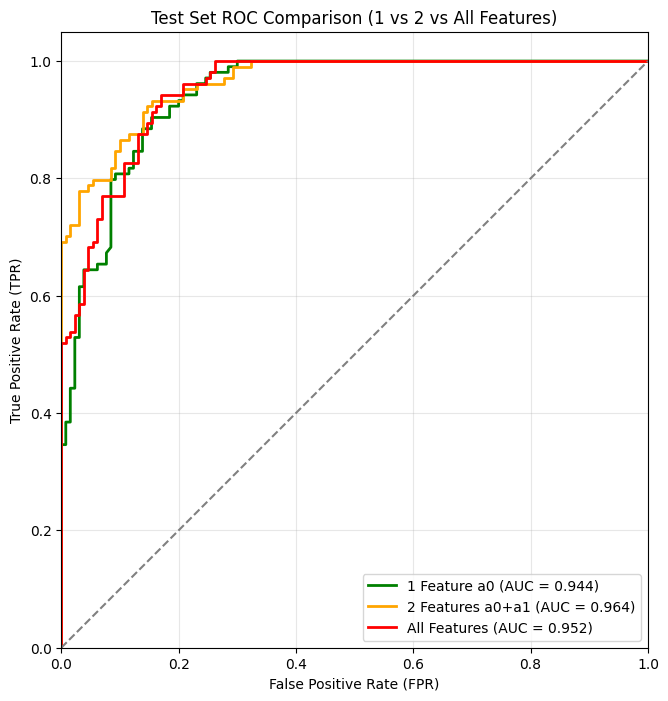

In [ ]:
features_all = ['a0', 'a1', 'a2', 'a3']
X_train_all = data_train[features_all]
X_test_all = data_test[features_all]

gnb_all = GaussianNB()
gnb_all.fit(X_train_all, y_train)

y_test_pred_all = gnb_all.predict(X_test_all)
y_test_proba_all = gnb_all.predict_proba(X_test_all)[:, 1]

cm_test_all = confusion_matrix(y_test, y_test_pred_all, normalize='true')
print("Normalized confusion matrix - Test set (All features):\n", cm_test_all)

auc_test_all = roc_auc_score(y_test, y_test_proba_all)

print(f"\n--- Comparison of AUC scores on Test Set ---")
print(f"1 Feature  (a0):         {auc_test_a0:.4f}")
print(f"2 Features (a0, a1):     {auc_test_a0a1:.4f}")
print(f"All Features (a0 to a3): {auc_test_all:.4f}")

fprs_test_all, tprs_test_all, _ = roc_curve(y_test, y_test_proba_all)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
plt.plot(fprs_test_a0, tprs_test_a0, color='green', lw=2, 
         label=f'1 Feature a0 (AUC = {auc_test_a0:.3f})')
plt.plot(fprs_test_a0a1, tprs_test_a0a1, color='orange', lw=2, 
         label=f'2 Features a0+a1 (AUC = {auc_test_a0a1:.3f})')
plt.plot(fprs_test_all, tprs_test_all, color='red', lw=2, 
         label=f'All Features (AUC = {auc_test_all:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Test Set ROC Comparison (1 vs 2 vs All Features)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()